In [1]:
from InSitu14CO import Propagator
import numpy as np
import matplotlib.pyplot as plt
import crflux.models as pm
import matplotlib.ticker as ticker
import matplotlib as mpl
import Functions_14CO as F

from tqdm import tqdm

import pandas as pd

from scipy import stats

import pyunfold as pu

In [2]:
def T(A):
    return np.swapaxes(A, -2, -1)

In [4]:
Prop = Propagator()
density_model = ('MSIS00', ('SouthPole', 'January'))
tag = 'DomeC'

In [5]:
df_Pfast = pd.read_csv('Production Rates/P_fast_SouthPole_3120m.csv')
df_Pneg = pd.read_csv('Production Rates/P_neg_SouthPole_3120m.csv')
P_14C = np.swapaxes([df_Pfast.T, df_Pneg.T], 0, 1)
model_names = list(df_Pfast.columns)

# The only production model being used is Heisinger
i = model_names.index('Heisinger')
prod_cut = np.arange(len(P_14C))[i:i+1]

In [6]:
Prop.Phi['prod']=P_14C[prod_cut]
C_flow_response = F.flow_14C_response(Prop)
C_response = C_flow_response @ Prop.S_mat[Prop.i_start:]

In [411]:
# SET TIME-DEPENDENT FLUX MODEL

t_bins = Prop.t_bins[Prop.i_start:]-Prop.t_bins[-1] # time in years, with 0=present
t = Prop.t[Prop.i_start:]-Prop.t_bins[-1]
t_scale = t/-t_bins[0] # time scaled from -1 to 0, with 0=present
t_bins_scale = (t_bins/-t_bins[0]).reshape((1,-1))
dt_bins_scale = np.diff(t_bins_scale,axis=-1)

N_poly = 5

f_poly = np.array([t_scale**i for i in range(N_poly)])

N_step = 100

#t_step = np.reshape(np.linspace(-1., 0., N_step+1), (-1,1))
#f_step = ((t_step[1:]-t_bins_scale[:,:-1]).clip(0,dt_bins_scale) - (t_step[:-1]-t_bins_scale[:,:-1]).clip(0,dt_bins_scale))/dt_bins_scale
t_step = np.reshape(np.arange(-1.,2./(N_step-1),1./(N_step-1)), (-1,1))
f_step = ((t_step[1:]-t_bins_scale[:,:-1]).clip(0,1./(N_step-1)) - (t_step[:-1]-t_bins_scale[:,:-1]).clip(0,1./(N_step-1)))*(N_step-1)

N_interp = 100

t_step = np.reshape(np.arange(-1.,2./(N_interp-1),1./(N_interp-1)), (-1,1))
f_interp = ((t_step[1:]-t_bins_scale[:,:-1]).clip(0,1./(N_interp-1)) - (t_step[:-1]-t_bins_scale[:,:-1]).clip(0,1./(N_interp-1)))*(N_interp-1)

N_fourier = 3
f_fourier = np.array([np.cos(np.pi*n*t_scale) for n in range(N_fourier+1)] + [np.sin(np.pi*n*t_scale) for n in range(1,N_fourier+1)])

f_fourier2 = np.array([np.cos(2*np.pi*n*t_scale) for n in range(N_fourier+1)] + [np.sin(2*np.pi*n*t_scale) for n in range(1,N_fourier+1)])

In [412]:
np.shape(f_fourier)

(7, 7283)

In [413]:
C_flow_poly = np.swapaxes(f_poly @ C_flow_response, 1,2)
C_flow_step = np.swapaxes(f_step @ C_flow_response, 1,2)
C_flow_interp = np.swapaxes(f_interp @ C_flow_response, 1,2)
C_flow_fourier = np.swapaxes(f_fourier @ C_flow_response, 1,2)
C_flow_fourier2 = np.swapaxes(f_fourier2 @ C_flow_response, 1,2)

In [414]:
C_poly = np.swapaxes(f_poly @ C_response, 1,2)
C_step = np.swapaxes(f_step @ C_response, 1,2)
C_interp = np.swapaxes(f_interp @ C_response, 1,2)
C_fourier = np.swapaxes(f_fourier @ C_response, 1,2)
C_fourier2 = np.swapaxes(f_fourier2 @ C_response, 1,2)

In [415]:
f_true = np.array([0.08,0.06])

In [416]:
CO_poly = f_true @ C_poly
CO_flow_poly = f_true @ C_flow_poly

CO_step = f_true @ C_step
CO_flow_step = f_true @ C_flow_step

CO_interp = f_true @ C_interp
CO_flow_interp = f_true @ C_flow_interp

CO_fourier = f_true @ C_fourier
CO_flow_fourier = f_true @ C_flow_fourier

CO_fourier2 = f_true @ C_fourier2
CO_flow_fourier2 = f_true @ C_flow_fourier2

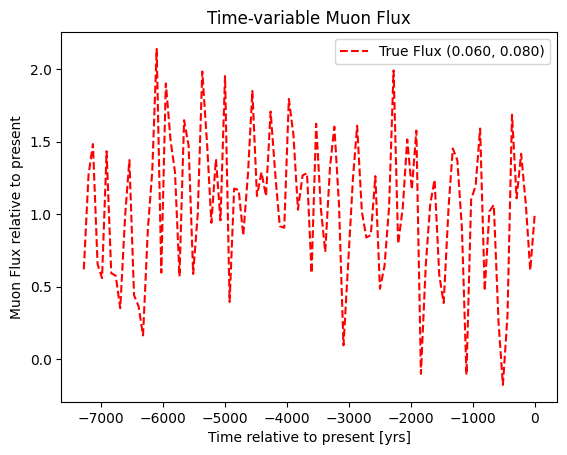

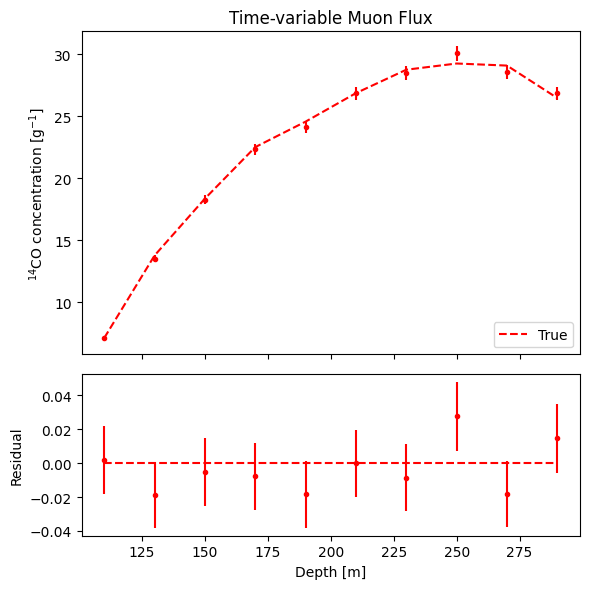

In [425]:
rel_err = 0.02
#rel_err = 0.

CO_samp = CO_interp[0]

#N = 1
amp = 0.1
s = np.random.normal(0,rel_err,(np.shape(CO_samp)[-1]))
f_samp = np.append(np.random.normal(1.,amp*np.sqrt(N_interp)/2,(len(CO_samp)-1)), 1.)
#f_samp = np.ones(len(Prop.z_samp))
#x = CO_avg_poly[0,0]*(1+s)
CO_true = f_samp @ CO_samp
CO_exp = CO_true*(1+s)
CO_err = CO_exp * rel_err

plt.plot(t,f_samp @ f_interp / (f_samp @ f_interp)[-1], ls='--', c='r', label='True Flux ({:.3f}, {:.3f})'.format(*np.flip(f_true)))
plt.xlabel('Time relative to present [yrs]')
plt.ylabel('Muon Flux relative to present')
plt.legend()
plt.title('Time-variable Muon Flux')
plt.show()


fig, (ax1,ax2) = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex=True, height_ratios=[2,1])

ax1.plot(Prop.z_samp, f_samp @ CO_samp, ls='--', c='r', label='True')
ax1.errorbar(Prop.z_samp, CO_exp, yerr=CO_err, fmt='.', c='r')

ax2.plot(Prop.z_samp, f_samp @ CO_samp / (f_samp @ CO_samp) -1, ls='--', c='r')
ax2.errorbar(Prop.z_samp, CO_exp / (f_samp @ CO_samp) -1, yerr=CO_err/ (f_samp @ CO_samp), fmt='.', c='r')

ax1.set(#xlabel='Depth [m]',
           #xscale='log',
           ylabel=r'$^{14}$CO concentration [g$^{-1}$]',
           #yscale='log',
      )
ax2.set(xlabel='Depth [m]',
           #xscale='log',
           ylabel='Residual',
           #yscale='log',
      )
ax1.title.set_text('Time-variable Muon Flux')
ax1.legend(loc='lower right')

plt.show()

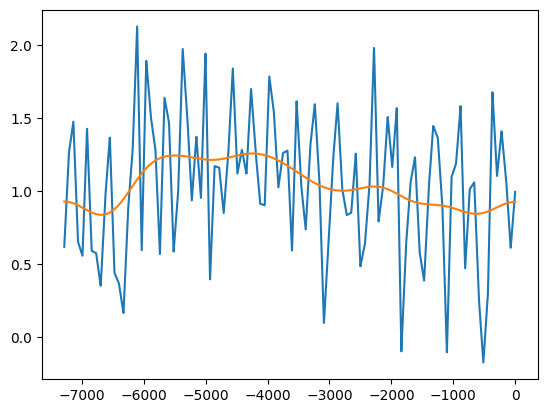

0.41223367826475615
0.14577032930264258


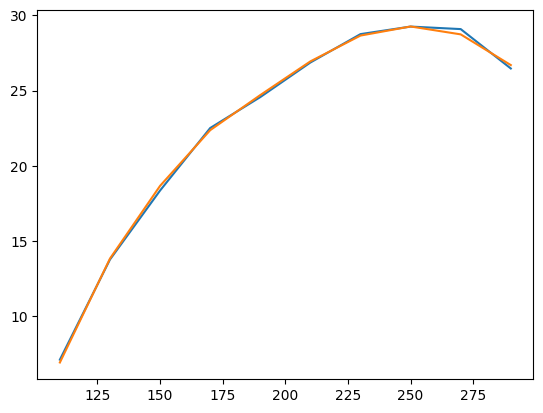

In [426]:
from scipy.ndimage import gaussian_filter

flux_true = f_samp @ f_interp
flux_blur = gaussian_filter(flux_true, sigma=(t_bins[-1]-t_bins[0])/20)
plt.plot(t, flux_true)
plt.plot(t, flux_blur)
plt.show()
print(np.std(flux_true))
print(np.std(flux_blur))

plt.plot(Prop.z_samp, f_samp @ CO_samp)
plt.plot(Prop.z_samp, f_true @ (flux_blur @ C_response)[0])
plt.show()

In [403]:
np.shape(C_response)

(1, 2, 7283, 10)

In [404]:
Sigma = np.diag(CO_err**2)
Sigma_inv = np.linalg.inv(Sigma)

C0 = np.sum(C_response, axis=-2)

f_hat_null = np.linalg.inv(C0 @ Sigma_inv @ T(C0)) @ C0 @ Sigma_inv @ CO_exp

chi2_true = 11.229437975887858
chi2_red_true = 1.122943797588786
p_true = 0.3399243777492823
sig_true = 0.9543146832682758

chi2_null = 22.83487213793918
chi2_red_null = 2.8543590172423974
p_null = 0.0035828480236896037
sigma_null = 2.9127295107828783



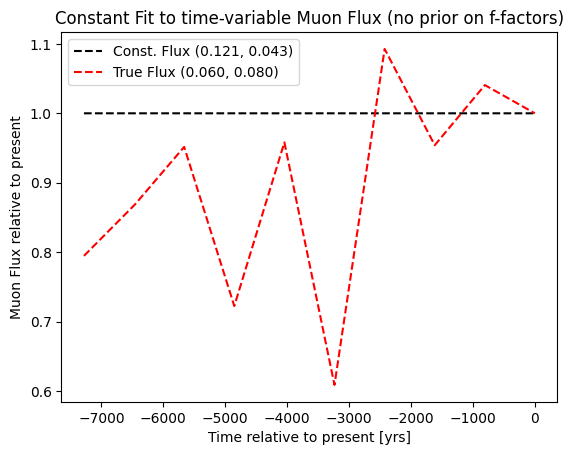

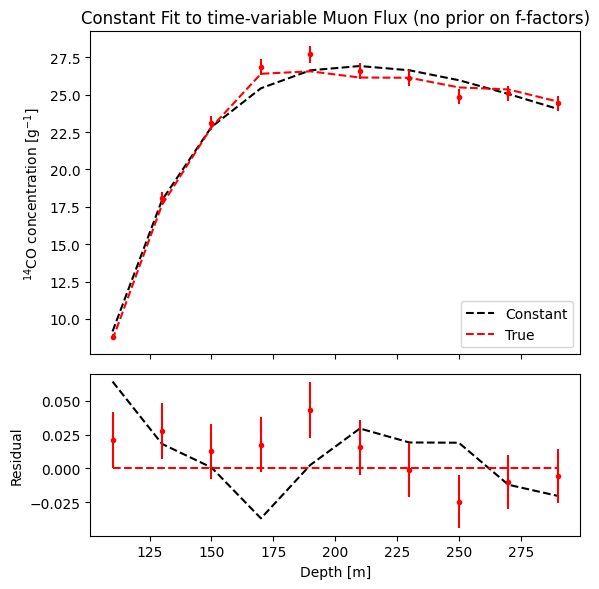

In [405]:
chi2_true = np.sum((s/rel_err)**2)
p_true = stats.chi2.sf(chi2_true, len(CO_exp))
sig_true = stats.norm.isf(p_true/2.)
print('chi2_true = {}'.format(chi2_true))
print('chi2_red_true = {}'.format(chi2_true / len(CO_exp)))
print('p_true = {}'.format(p_true))
print('sig_true = {}'.format(sig_true))
print()

CO_null = np.sum(f_hat_null.reshape((*np.shape(f_hat_null),1)) * C0, axis=-2) 
chi2_null = np.sum((CO_null - CO_exp) @ Sigma_inv *(CO_null - CO_exp), axis=-1)[0]
p_null = stats.chi2.sf(chi2_null, len(CO_exp)-len(f_hat_null[0]))
sig_null = stats.norm.isf(p_null/2.)
print('chi2_null = {}'.format(chi2_null))
print('chi2_red_null = {}'.format(chi2_null / (len(CO_exp)-len(f_true))))
print('p_null = {}'.format(p_null))
print('sigma_null = {}'.format(sig_null))
print()

plt.plot(t, t*0. + 1., ls='--', c='k', label='Const. Flux ({:.3f}, {:.3f})'.format(*np.flip(f_hat_null[0])))
plt.plot(t,f_samp @ f_interp / (f_samp @ f_interp)[-1], ls='--', c='r', label='True Flux ({:.3f}, {:.3f})'.format(*np.flip(f_true)))
plt.xlabel('Time relative to present [yrs]')
plt.ylabel('Muon Flux relative to present')
plt.legend()
plt.title('Constant Fit to time-variable Muon Flux (no prior on f-factors)')
plt.show()


fig, (ax1,ax2) = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex=True, height_ratios=[2,1])

ax1.plot(Prop.z_samp, f_hat_null[0] @ C0[0], ls='--', c='k', label='Constant')
ax1.plot(Prop.z_samp, f_samp @ CO_samp, ls='--', c='r', label='True')
ax1.errorbar(Prop.z_samp, CO_exp, yerr=CO_err, fmt='.', c='r')

ax2.plot(Prop.z_samp, f_hat_null[0] @ C0[0] / (f_samp @ CO_samp) -1, ls='--', c='k')
ax2.plot(Prop.z_samp, f_samp @ CO_samp / (f_samp @ CO_samp) -1, ls='--', c='r')
ax2.errorbar(Prop.z_samp, CO_exp / (f_samp @ CO_samp) -1, yerr=CO_err/ (f_samp @ CO_samp), fmt='.', c='r')

ax1.set(#xlabel='Depth [m]',
           #xscale='log',
           ylabel=r'$^{14}$CO concentration [g$^{-1}$]',
           #yscale='log',
      )
ax2.set(xlabel='Depth [m]',
           #xscale='log',
           ylabel='Residual',
           #yscale='log',
      )
ax1.title.set_text('Constant Fit to time-variable Muon Flux (no prior on f-factors)')
ax1.legend(loc='lower right')

plt.show()

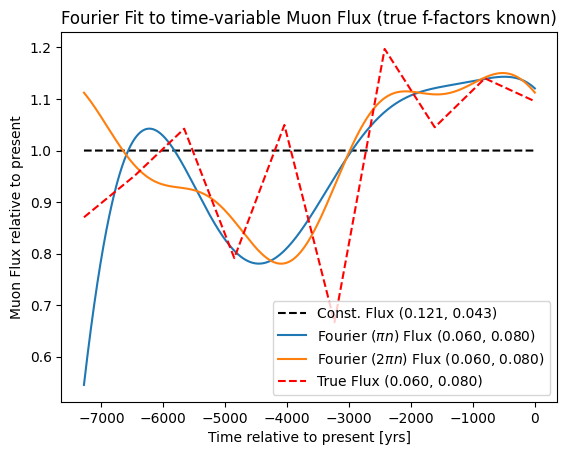

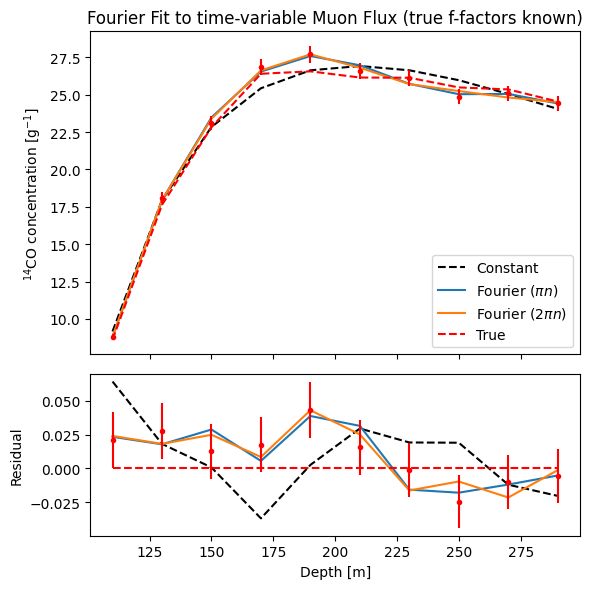

In [406]:
a_hat_fourier = np.linalg.inv(CO_fourier @ Sigma_inv @ T(CO_fourier)) @ CO_fourier @ Sigma_inv @ CO_exp

a_hat_fourier2 = np.linalg.inv(CO_fourier2 @ Sigma_inv @ T(CO_fourier2)) @ CO_fourier2 @ Sigma_inv @ CO_exp

plt.plot(t, t*0. + 1., ls='--', c='k', label='Const. Flux ({1:.3f}, {0:.3f})'.format(*f_hat_null[0]))
plt.plot(t, a_hat_fourier[0] @ f_fourier, label=r'Fourier ($\pi n$) Flux ({1:.3f}, {0:.3f})'.format(*f_true))
plt.plot(t, a_hat_fourier2[0] @ f_fourier2, label=r'Fourier ($2\pi n$) Flux ({1:.3f}, {0:.3f})'.format(*f_true))
plt.plot(t,f_samp @ f_interp, ls='--', c='r', label='True Flux ({1:.3f}, {0:.3f})'.format(*f_true))
plt.xlabel('Time relative to present [yrs]')
plt.ylabel('Muon Flux relative to present')
plt.legend()
plt.title('Fourier Fit to time-variable Muon Flux (true f-factors known)')
plt.show()

fig, (ax1,ax2) = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex=True, height_ratios=[2,1])

ax1.plot(Prop.z_samp, f_hat_null[0] @ C0[0], ls='--', c='k', label='Constant')
ax1.plot(Prop.z_samp, a_hat_fourier[0] @ CO_fourier[0], label=r'Fourier ($\pi n$)')
ax1.plot(Prop.z_samp, a_hat_fourier2[0] @ CO_fourier2[0], label=r'Fourier ($2\pi n$)')
ax1.plot(Prop.z_samp, f_samp @ CO_samp, ls='--', c='r', label='True')
ax1.errorbar(Prop.z_samp, CO_exp, yerr=CO_err, fmt='.', c='r')

ax2.plot(Prop.z_samp, f_hat_null[0] @ C0[0] / (f_samp @ CO_samp) -1, ls='--', c='k')
ax2.plot(Prop.z_samp, a_hat_fourier[0] @ CO_fourier[0] / (f_samp @ CO_samp) -1)
ax2.plot(Prop.z_samp, a_hat_fourier2[0] @ CO_fourier2[0] / (f_samp @ CO_samp) -1)
ax2.plot(Prop.z_samp, f_samp @ CO_samp / (f_samp @ CO_samp) -1, ls='--', c='r')
ax2.errorbar(Prop.z_samp, CO_exp / (f_samp @ CO_samp) -1, yerr=CO_err/ (f_samp @ CO_samp), fmt='.', c='r')

ax1.set(#xlabel='Depth [m]',
           #xscale='log',
           ylabel=r'$^{14}$CO concentration [g$^{-1}$]',
           #yscale='log',
      )
ax2.set(xlabel='Depth [m]',
           #xscale='log',
           ylabel='Residual',
           #yscale='log',
      )
ax1.title.set_text('Fourier Fit to time-variable Muon Flux (true f-factors known)')
ax1.legend(loc='lower right')

plt.show()